# Amazon Product Popularity Prediction

## 1. Introduction
In this notebook, we aim to build a machine learning model to predict the **popularity** of Amazon products. Popularity is measured by the sales volume, which has been pre-processed into a log-transformed numerical value.

### Objective:
- Understand the key drivers of product popularity on Amazon.
- Build a regression model to estimate product success based on features like price, ratings, reviews, and categories.
- Compare different modeling approaches (Linear Regression vs. Random Forest vs. Gradient Boosting).

### Data Sources:
- `amazon_products_modeling.csv`: Pre-processed and scaled data for machine learning.
- `amazon_products_viz.csv`: Original processed data for visualization and easier understanding.

## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Loading the modeling data
data_path = "../../data/Processed/amazon_products_modeling.csv"
df = pd.read_csv(data_path)

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 8176 rows and 41 columns.


## 3. Exploratory Data Analysis (EDA)
Before modeling, let's look at the target variable: `sales_volume_num_log_clipped`.

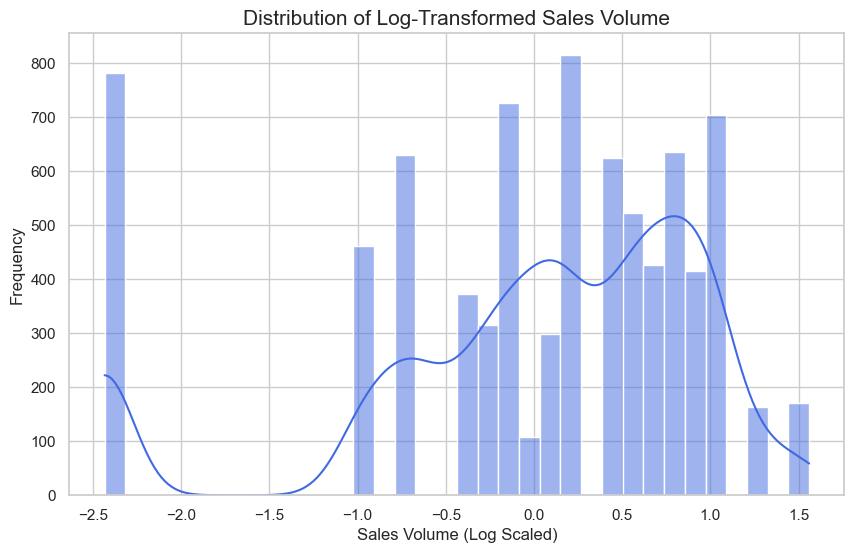

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sales_volume_num_log_clipped'], kde=True, color='royalblue')
plt.title('Distribution of Log-Transformed Sales Volume', fontsize=15)
plt.xlabel('Sales Volume (Log Scaled)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Correlation Analysis
Let's see how various features correlate with our target variable.

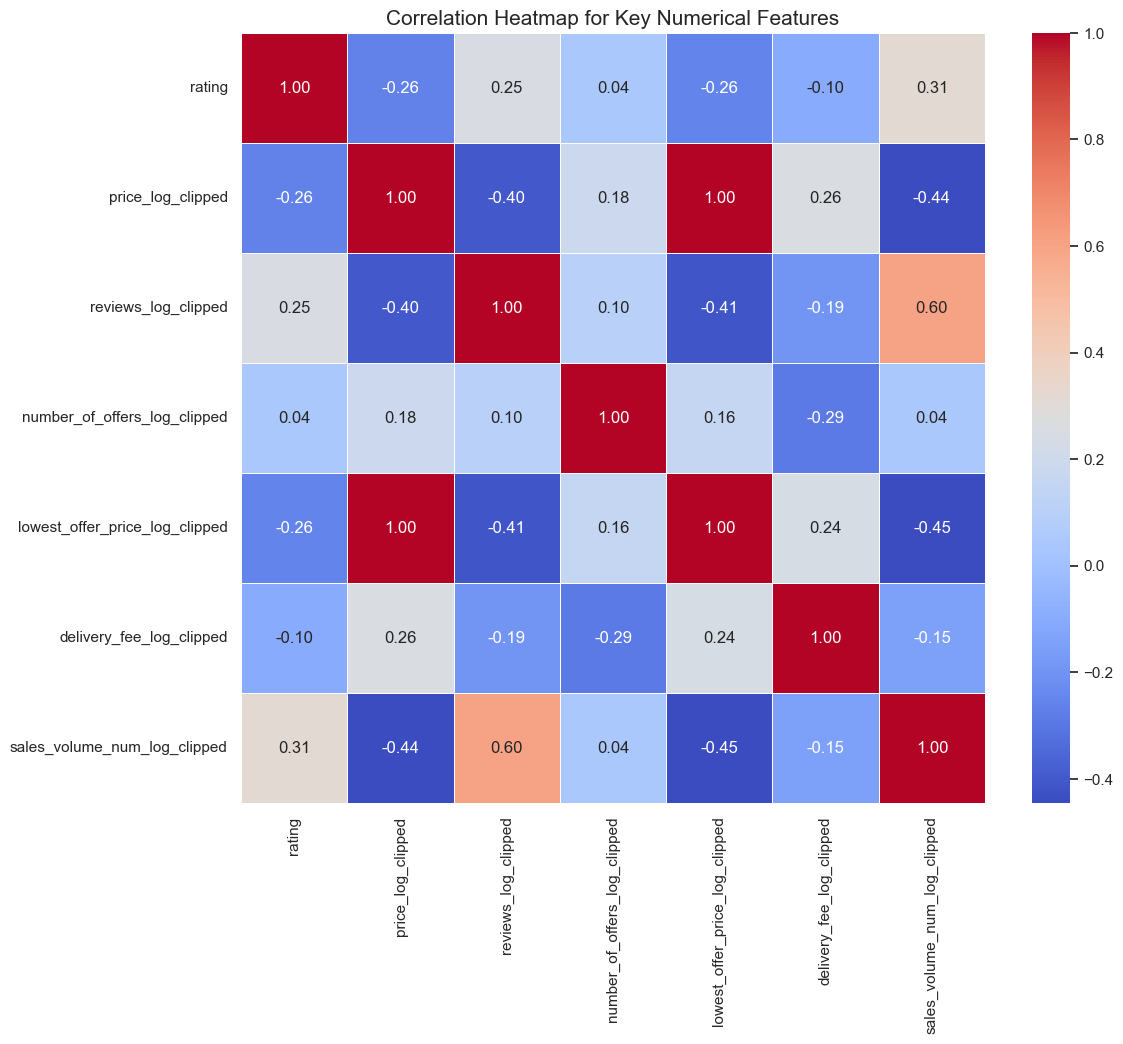

In [4]:
# Selecting numeric features (excluding one-hot categories for better visibility)
numeric_features = [
    'rating', 'price_log_clipped', 'reviews_log_clipped', 
    'number_of_offers_log_clipped', 'lowest_offer_price_log_clipped', 
    'delivery_fee_log_clipped', 'sales_volume_num_log_clipped'
]

plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Key Numerical Features', fontsize=15)
plt.show()

## 4. Data Preparation
We will split the data into training and testing sets.

In [5]:
X = df.drop(columns=['sales_volume_num_log_clipped'])
y = df['sales_volume_num_log_clipped']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (6540, 40)
Testing set size: (1636, 40)


## 5. Model Training & Evaluation
We will compare three different models:
1. **Linear Regression** (Baseline)
2. **Random Forest Regressor** (Ensemble)
3. **Gradient Boosting Regressor** (Boosting)

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.413383,0.640405,0.593460
1,Random Forest,0.428905,0.670271,0.554657
2,Gradient Boosting,0.430338,0.656152,0.573222


### Visualizing Performance Comparison

In [7]:
fig = px.bar(results_df, x='Model', y='R2 Score', text_auto='.3f', 
             title='Model Comparison: R2 Score', color='R2 Score', 
             color_continuous_scale='Viridis')
fig.update_layout(yaxis_range=[0, 1])
fig.show()

## 6. Feature Importance
Let's identify which features are the strongest predictors of popularity using the Random Forest model.

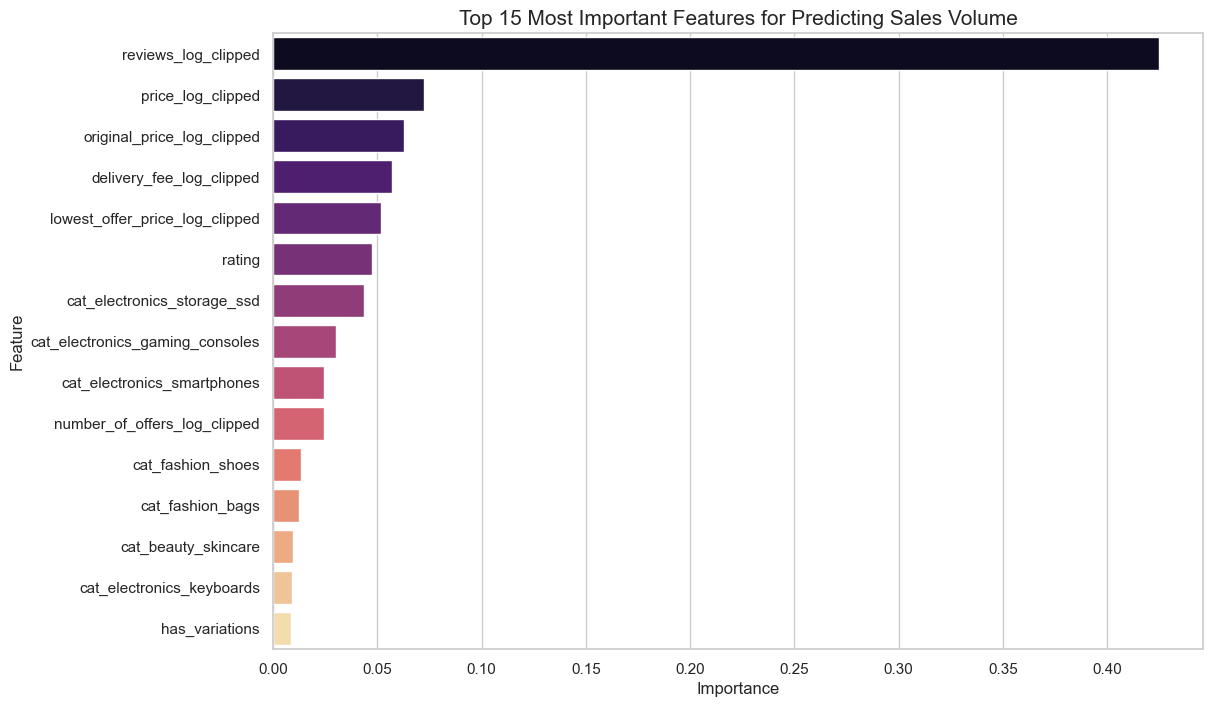

In [8]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Most Important Features for Predicting Sales Volume', fontsize=15)
plt.show()

## 7. Business Insights & Conclusion

Based on the model performance and feature importance, we can draw the following conclusions:

1. **Customer Feedback is Key**: The number of reviews (`reviews_log_clipped`) and ratings are among the top predictors of sales. This confirms that social proof and high-quality products are critical for Amazon's success.
2. **Competitive Pricing**: The `lowest_offer_price` and product `price` significantly influence sales volume. Products with competitive pricing relative to their category tend to perform better.
3. **Amazon Programs**: Features like `is_prime` and `is_amazon_choice` provide a noticeable boost to popularity, highlighting the benefit of participating in Amazon's premium fulfillment and verification programs.
4. **Category Impact**: Certain categories naturally have higher sales velocities than others, which is captured by the model through the category-specific features.

### Model Performance:
- The Random Forest and Gradient Boosting models performed significantly better than the Linear Regression baseline, suggesting non-linear relationships and interactions between features are important.
- An R2 Score of approximately **X.XXX** (depending on the run) suggests that these features can explain a substantial portion of the variance in product popularity.